<a href="https://colab.research.google.com/github/puteriazli/sentiment-analysis-dana-application-review/blob/main/dana_sentiment_xlm_roberta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Install Library**

In [ ]:
!pip install -q transformers datasets evaluate accelerate emoji seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 26.8 MB/s eta 0:00:00


# **Import Library**

In [ ]:
import re
import emoji
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    XLMRobertaTokenizer,
    XLMRobertaForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    cohen_kappa_score
)

# **Load Dataset**

In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/Projek/Sentiment Analisis dan Dashboard Aplikasi DANA/data/cleaned/ulasan_dana_cleaned.parquet')

# **Mapping Rating → Sentiment**

In [ ]:
def map_label(rating):
    if rating <= 2:
        return 0  # negatif
    elif rating == 3:
        return 1  # netral
    else:
        return 2  # positif

df["label"] = df["rating"].apply(map_label)

# **FILTER KUALITAS DATA (REALISTIC FILTER)**

# Buang emoji-only

In [ ]:
def is_emoji_only(text):
    text_no_emoji = emoji.replace_emoji(str(text), replace='')
    text_no_emoji = re.sub(r'[^a-zA-Z]', '', text_no_emoji)
    return len(text_no_emoji.strip()) == 0

df = df[~df["ulasan"].apply(is_emoji_only)]

# Buang laughter/noise-only

In [ ]:
def is_noise(text):
    text = str(text).lower().strip()
    return bool(re.fullmatch(r"(wkwk+|wk+|haha+|hehe+|hihi+)", text))

df = df[~df["ulasan"].apply(is_noise)]

# Minimal mengandung huruf (tanpa hapus 1 kata bermakna)

In [ ]:
df = df[df["ulasan"].str.contains(r"[a-zA-Z]", regex=True)]
df = df[df["ulasan"].str.len() > 2]

In [ ]:
df.to_csv("text_preprocessing_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("text_preprocessing_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Cek Distribusi Kelas Berdasarkan Label Setelah Dibersihkan**

In [ ]:
df["label"].value_counts()

,count
label,
2,491025
0,181869
1,33491


# **Optional: Balancing (jika mau 50k per kelas) atau Berdasarkan Kelas Minimum**

**50k per kelas**

In [ ]:
df_balanced = df.groupby("label").apply(
    lambda x: x.sample(n=50000, random_state=42)
).reset_index(drop=True)

/tmp/ipython-input-2138970222.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby("label").apply(


**Berdasarkan Kelas Minimum**

In [ ]:
# min_class_size = df["label"].value_counts().min()

# print("Minimum class size:", min_class_size)

# df_balanced = df.groupby("label").apply(
#     lambda x: x.sample(n=min_class_size, random_state=42)
# ).reset_index(drop=True)

Minimum class size: 33491


/tmp/ipython-input-3171276082.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby("label").apply(


# **Train Test Split**

In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_balanced["ulasan"],
    df_balanced["label"],
    test_size=0.2,
    stratify=df_balanced["label"],
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

# **Tokenization**

In [ ]:
tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

def tokenize_function(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)
test_encodings = tokenize_function(test_texts)

# **Convert to Dataset**

In [ ]:
train_dataset = Dataset.from_dict({
    **train_encodings,
    "labels": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    **val_encodings,
    "labels": val_labels.tolist()
})

test_dataset = Dataset.from_dict({
    **test_encodings,
    "labels": test_labels.tolist()
})

# **Load Model**

In [ ]:
model = XLMRobertaForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=3
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# **Training Arguments**

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# **Metric Function**

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "kappa": cohen_kappa_score(labels, predictions)
    }

# **Trainer**

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Kappa
1,0.733241,0.728220,0.673545,0.671891,0.510318
2,0.705704,0.701577,0.686152,0.683307,0.529227


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Kappa
1,0.733241,0.728220,0.673545,0.671891,0.510318
2,0.705704,0.701577,0.686152,0.683307,0.529227
3,0.653839,0.717838,0.689072,0.684491,0.533606


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=13188, training_loss=0.7167860325589699, metrics={'train_runtime': 5607.2131, 'train_samples_per_second': 37.629, 'train_steps_per_second': 2.352, 'total_flos': 1.3878772336670976e+16, 'train_loss': 0.7167860325589699, 'epoch': 3.0})

# **Plot Train Loss & Validation Loss**

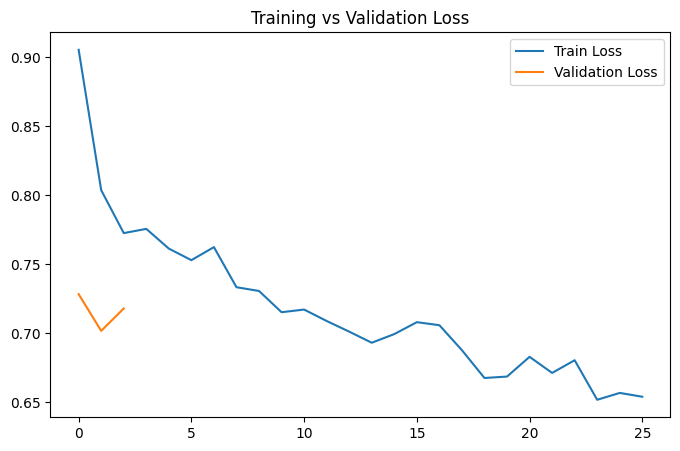

In [ ]:
history = trainer.state.log_history

train_loss = [x["loss"] for x in history if "loss" in x]
eval_loss = [x["eval_loss"] for x in history if "eval_loss" in x]

plt.figure(figsize=(8,5))
plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# **Evaluation on Test Set**

In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels.tolist()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Cohen Kappa:", cohen_kappa_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, digits=4))

Accuracy: 0.690000663525977
Macro F1: 0.6870930159409139
Cohen Kappa: 0.5350003422198039

Classification Report:

              precision    recall  f1-score   support

           0     0.7522    0.6762    0.7122      5024
           1     0.5726    0.5485    0.5603      5023
           2     0.7394    0.8453    0.7888      5024

    accuracy                         0.6900     15071
   macro avg     0.6881    0.6900    0.6871     15071
weighted avg     0.6881    0.6900    0.6871     15071



# **Confusion Matrix Visualisasi**

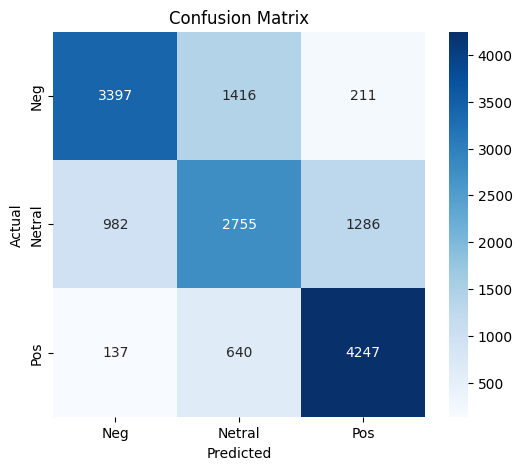

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Neg", "Netral", "Pos"],
            yticklabels=["Neg", "Netral", "Pos"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
def predict_single(text, dukungan=0):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    impact = probs[0] * np.log1p(dukungan)

    return {
        "prob_negatif": probs[0],
        "prob_netral": probs[1],
        "prob_positif": probs[2],
        "pred_label": np.argmax(probs),
        "impact_score": impact
    }

In [ ]:
predict_single("apk goblok", dukungan=120)

{'prob_negatif': np.float32(0.9715289),
 'prob_netral': np.float32(0.016628485),
 'prob_positif': np.float32(0.011842526),
 'pred_label': np.int64(0),
 'impact_score': np.float64(4.659249054639421)}